### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from gensim.models import Word2Vec
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to C:\Users\Care
[nltk_data]     Pix\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Care
[nltk_data]     Pix\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Care
[nltk_data]     Pix\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Task 1 :

### Data Collection and Preprocessing

In [2]:
df = pd.read_csv("data_news - data_news.csv")
df.head()

,category,headline,links,short_description,keywords
0,WELLNESS,143 Miles in 35 Days: Lessons Learned,https://www.huffingtonpost.com/entry/running-l...,Resting is part of training. I've confirmed wh...,running-lessons
1,WELLNESS,Talking to Yourself: Crazy or Crazy Helpful?,https://www.huffingtonpost.com/entry/talking-t...,Think of talking to yourself as a tool to coac...,talking-to-yourself-crazy
2,WELLNESS,Crenezumab: Trial Will Gauge Whether Alzheimer...,https://www.huffingtonpost.com/entry/crenezuma...,The clock is ticking for the United States to ...,crenezumab-alzheimers-disease-drug
3,WELLNESS,"Oh, What a Difference She Made",https://www.huffingtonpost.com/entry/meaningfu...,"If you want to be busy, keep trying to be perf...",meaningful-life
4,WELLNESS,Green Superfoods,https://www.huffingtonpost.com/entry/green-sup...,"First, the bad news: Soda bread, corned beef a...",green-superfoods


In [3]:
#Checking datatype in each available column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   category           50000 non-null  object
 1   headline           50000 non-null  object
 2   links              50000 non-null  object
 3   short_description  50000 non-null  object
 4   keywords           47332 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [4]:
# Check for missing values

df.isnull().sum()

category                0
headline                0
links                   0
short_description       0
keywords             2668
dtype: int64

In [5]:
# Filling missing values and dropping unnecessary columns

df['keywords']=df['keywords'].fillna(' ')
df.drop('links', axis=1, inplace=True)
df.isnull().sum()

category             0
headline             0
short_description    0
keywords             0
dtype: int64

Note :

- An empty string won't affect the vectorization of the other columns.
- The column 'links' in the dataset contain URL's which does not help with classification models.

In [6]:
# Checking for unique value in target column

df['category'].unique()

array(['WELLNESS', 'POLITICS', 'ENTERTAINMENT', 'TRAVEL',
       'STYLE & BEAUTY', 'PARENTING', 'FOOD & DRINK', 'WORLD NEWS',
       'BUSINESS', 'SPORTS'], dtype=object)

In [7]:
# Checking the count of each value in categoru column

df['category'].value_counts()

category
WELLNESS          5000
POLITICS          5000
ENTERTAINMENT     5000
TRAVEL            5000
STYLE & BEAUTY    5000
PARENTING         5000
FOOD & DRINK      5000
WORLD NEWS        5000
BUSINESS          5000
SPORTS            5000
Name: count, dtype: int64

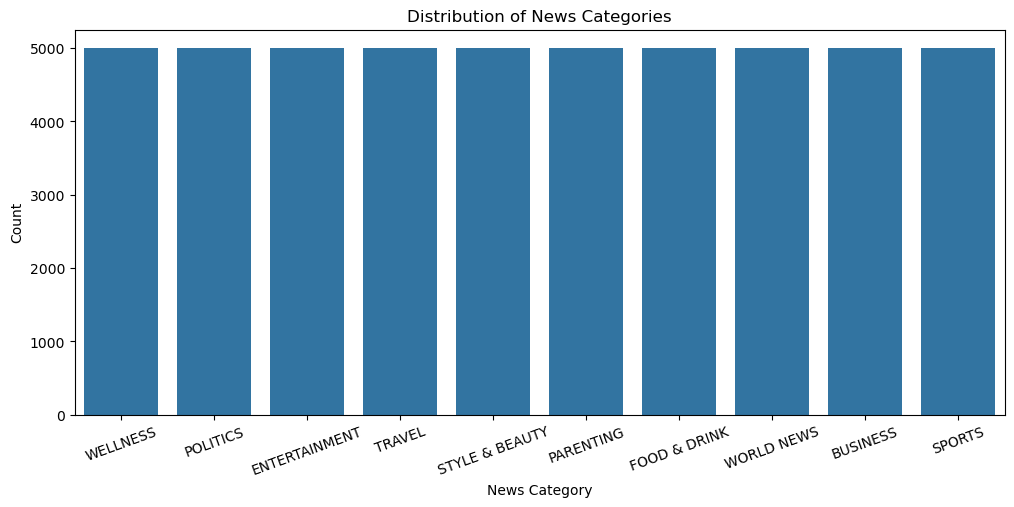

In [8]:
# Visualization of distribution

plt.figure(figsize=(12,5))
sns.countplot(x=df['category'])
plt.title("Distribution of News Categories")
plt.xlabel("News Category")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

Observations :

- The dataset is good for classification tasks because it is perfectly balanced.

In [9]:
# Checking text Length 

short_des_len = df['short_description'].str.len().describe()
headline_len = df['headline'].str.len().describe()

print("Text Length Analysis - Short Description:\n", short_des_len)
print("\nText Length Analysis - Headline:\n", headline_len)

Text Length Analysis - Short Description:
 count    50000.000000
mean       133.350120
std         77.789444
min          1.000000
25%         82.000000
50%        122.000000
75%        167.000000
max       1392.000000
Name: short_description, dtype: float64

Text Length Analysis - Headline:
 count    50000.000000
mean        56.820580
std         19.429163
min          4.000000
25%         43.000000
50%         57.000000
75%         70.000000
max        295.000000
Name: headline, dtype: float64


In [11]:
# Checking for outliers which has legth less than 5

df['description_length'] = df['short_description'].str.len()
short_description_check = df['description_length'] <= 5
short_articles = df[short_description_check]
short_articles

,category,headline,short_description,keywords,description_length
5812,POLITICS,West Virginia Governor Brings Out Actual Bulls...,💩,jim-justice-budget-bill,1
8271,POLITICS,Here's What Would Have To Happen For Jeb Bush ...,💋,jeb-bush-warm-kiss,1
10616,ENTERTAINMENT,"This Is Where The Word 'Meme' Comes From, And ...",Huh!,origin-word-meme,4
11719,ENTERTAINMENT,Fleetwood Mac's Lindsey Buckingham And Christi...,🙌 🙌 🙌,christine-mcvie-lindsey-buckingham-duets-album,5
12580,ENTERTAINMENT,Jennifer Lawrence And Chris Pratt Are In A Lea...,OUCH!,jennifer-lawrence-chris-pratt-insults,5
12719,ENTERTAINMENT,Ariana Grande Gives Fans Singing 'One Last Tim...,OMG!,ariana-grande-surprises-fans,4
13458,ENTERTAINMENT,Teen Wolf' Actors Say Their Goodbyes To The Se...,😭 😭 😭,teen-wolf-wraps-filming-actor-goodbyes,5
15111,TRAVEL,A Friendly Reminder That There Were 0 Fatal Je...,👍👏,fatal-jet-accident-rate,2
15302,TRAVEL,You Can Order Room Service With Emojis. Peak L...,👏🏨 💥,emoji-room-service-aloft-hotels,4
20606,STYLE & BEAUTY,Kim Kardashian Accessorizes With A Kitten (PHOTO),Meow!,kim-kardashian-2012-photo,5


Observations :

- A small number of articles had very short descriptions(≤ 5 characters). 
- These description are considered as noise and meaningless.

In [12]:
# Removing rows where description length ≤ 5
df_cleaned = df[df['description_length'] > 5].copy()
rows_dropped = len(df) - len(df_cleaned)

In [13]:
# Checking the total row count after dropping

print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count: {len(df_cleaned)}")
print(f"Total Rows Dropped (Noise): {rows_dropped}")

Original Row Count: 50000
Cleaned Row Count: 49965
Total Rows Dropped (Noise): 35


In [14]:
# Combining headline + description + keywords

df_cleaned['combined_text'] = (df_cleaned['headline'].astype(str) + ' ' +
    df_cleaned['short_description'].astype(str) + ' ' +
    df_cleaned['keywords'].astype(str)
)

#### Data Preprocessing :

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text Pre-processing Function

def preprocess_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

In [16]:
df_cleaned['clean_combinedtext'] = df_cleaned['combined_text'].apply(preprocess_text)
df_cleaned[['combined_text', 'clean_combinedtext']].head()

,combined_text,clean_combinedtext
0,143 Miles in 35 Days: Lessons Learned Resting ...,143 mile 35 day lesson learned resting part tr...
1,Talking to Yourself: Crazy or Crazy Helpful? T...,talking crazy crazy helpful think talking tool...
2,Crenezumab: Trial Will Gauge Whether Alzheimer...,crenezumab trial gauge whether alzheimer drug ...
3,"Oh, What a Difference She Made If you want to ...",oh difference made want busy keep trying perfe...
4,"Green Superfoods First, the bad news: Soda bre...",green superfoods first bad news soda bread cor...


## Task 2 :

### Feature Engineering

In [17]:
le = LabelEncoder()

X = df_cleaned['clean_combinedtext']
y = le.fit_transform(df_cleaned['category'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [18]:
# Creating BoW Model

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [19]:
# Creating Word2Vec model

tokenized_text = df_cleaned['clean_combinedtext'].apply(lambda x: x.split())

# Training Word2Vec model
w2v_model = Word2Vec(sentences = tokenized_text, vector_size = 100, window = 5, min_count = 2, workers = 4, sg = 1)

# Function for creating average Word2Vec vector for each review
def get_avg_vector(tokens):
    vector = np.zeros(100)
    count = 0
    for word in tokens:
        if word in w2v_model.wv:
            vector += w2v_model.wv[word]
            count += 1
    return vector / count if count != 0 else vector

df_cleaned['word2vec_vector'] = tokenized_text.apply(get_avg_vector)
df_cleaned[['clean_combinedtext','word2vec_vector']].head()

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


,clean_combinedtext,word2vec_vector
0,143 mile 35 day lesson learned resting part tr...,"[-0.050414799027411, 0.23649745854948248, 0.07..."
1,talking crazy crazy helpful think talking tool...,"[-0.020962388787761722, 0.18067822056381325, 0..."
2,crenezumab trial gauge whether alzheimer drug ...,"[0.05371071169308076, 0.35666272323578596, -0...."
3,oh difference made want busy keep trying perfe...,"[-0.09857002437735597, 0.16260130976637205, 0...."
4,green superfoods first bad news soda bread cor...,"[-0.1278930271877662, 0.13015006173794208, 0.1..."


##### The above are some exception which do not affect the models hence we can ignore them.

In [20]:
# # Creating TF-IDF model

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

#### Textual features :

Used metrics like word count, character count, average word length to capture structural style of text.

In [21]:
# Word Count
df_cleaned['word_count'] = df_cleaned['clean_combinedtext'].apply(lambda x: len(x.split()))

# Character Count
df_cleaned['char_count'] = df_cleaned['clean_combinedtext'].apply(len)

# Average Word Length
df_cleaned['avg_word_length'] = df_cleaned['clean_combinedtext'].apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)

df_cleaned[['word_count','char_count','avg_word_length']].head()

,word_count,char_count,avg_word_length
0,35,228,5.542857
1,20,137,5.900000
2,25,177,6.120000
3,15,99,5.666667
4,19,121,5.421053


In [22]:
text_features = df_cleaned[['word_count', 'char_count', 'avg_word_length']]

# Spliting them according to the same indices as TF-IDF
X_train_text = text_features.loc[X_train.index]
X_test_text = text_features.loc[X_test.index]

In [23]:
from scipy.sparse import csr_matrix

X_train_text_sparse = csr_matrix(X_train_text.values)
X_test_text_sparse = csr_matrix(X_test_text.values)

In [24]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_text_sparse])
X_test_combined = hstack([X_test_tfidf, X_test_text_sparse])

## Task 3 and 4 :

### Model Development and Evaluation

Accuracy: 0.8137
ROC-AUC: 0.9755

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.78      0.78       999
           1       0.79      0.82      0.80       999
           2       0.86      0.87      0.87      1000
           3       0.80      0.77      0.78      1000
           4       0.78      0.76      0.77      1000
           5       0.87      0.90      0.88       997
           6       0.88      0.85      0.87       999
           7       0.81      0.80      0.81      1000
           8       0.76      0.79      0.77      1000
           9       0.81      0.81      0.81       999

    accuracy                           0.81      9993
   macro avg       0.81      0.81      0.81      9993
weighted avg       0.81      0.81      0.81      9993



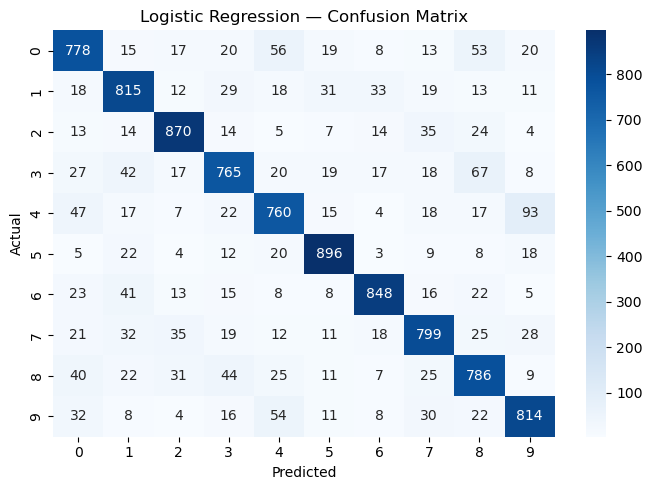

Accuracy: 0.8024
ROC-AUC: 0.9748

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       999
           1       0.80      0.77      0.79       999
           2       0.86      0.87      0.86      1000
           3       0.75      0.76      0.76      1000
           4       0.79      0.74      0.76      1000
           5       0.88      0.85      0.87       997
           6       0.86      0.83      0.85       999
           7       0.78      0.83      0.80      1000
           8       0.75      0.80      0.77      1000
           9       0.79      0.83      0.81       999

    accuracy                           0.80      9993
   macro avg       0.80      0.80      0.80      9993
weighted avg       0.80      0.80      0.80      9993



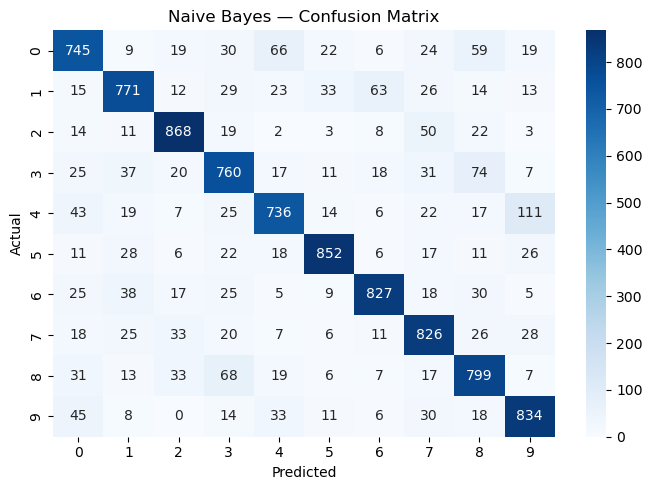

Accuracy: 0.8169
ROC-AUC: 0.9712

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       999
           1       0.80      0.79      0.79       999
           2       0.86      0.88      0.87      1000
           3       0.81      0.76      0.78      1000
           4       0.79      0.75      0.77      1000
           5       0.87      0.93      0.90       997
           6       0.88      0.87      0.87       999
           7       0.82      0.80      0.81      1000
           8       0.77      0.77      0.77      1000
           9       0.81      0.81      0.81       999

    accuracy                           0.82      9993
   macro avg       0.82      0.82      0.82      9993
weighted avg       0.82      0.82      0.82      9993



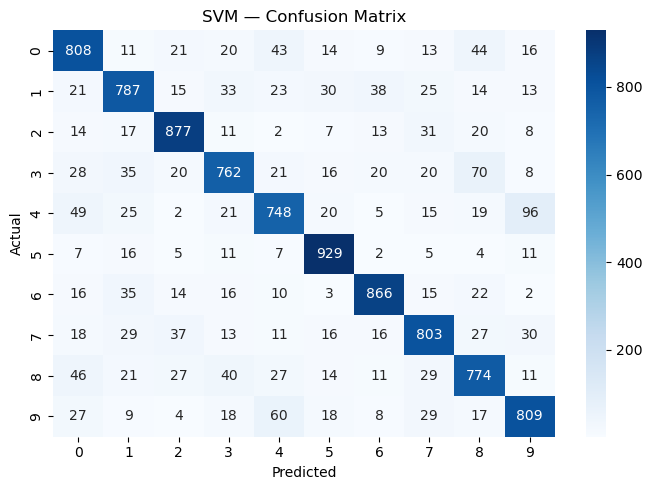

Accuracy: 0.7364
ROC-AUC: 0.96

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.79      0.80       999
           1       0.62      0.69      0.65       999
           2       0.72      0.82      0.76      1000
           3       0.73      0.76      0.74      1000
           4       0.72      0.63      0.67      1000
           5       0.86      0.91      0.88       997
           6       0.79      0.80      0.79       999
           7       0.74      0.62      0.67      1000
           8       0.68      0.67      0.67      1000
           9       0.72      0.67      0.70       999

    accuracy                           0.74      9993
   macro avg       0.74      0.74      0.74      9993
weighted avg       0.74      0.74      0.74      9993



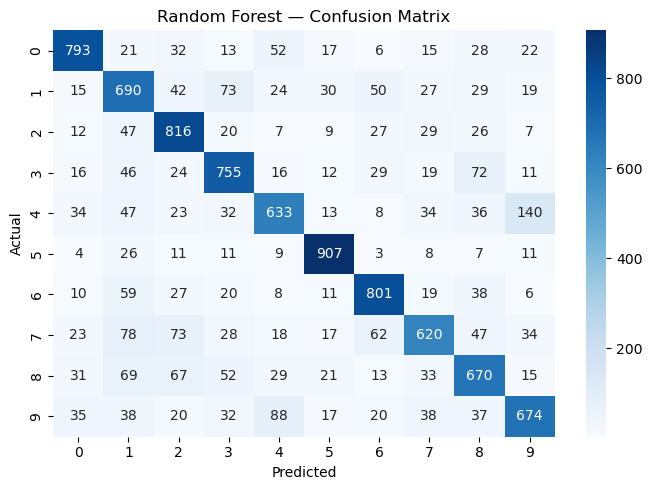

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
classes = np.unique(y_train)

for name, model in models.items():
    model.fit(X_train_combined, y_train)
    y_pred = model.predict(X_test_combined)
    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_combined)
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test_combined)
    if y_proba is not None:
        try:
            y_test_bin = label_binarize(y_test, classes=classes)
            roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr")
        except:
            roc_auc = np.nan
    else:
        roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {round(acc,4)}")
    print(f"ROC-AUC: {round(roc_auc,4) if not np.isnan(roc_auc) else 'N/A'}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    results.append((name, acc, roc_auc))

    # Plotting using Confusion Matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',xticklabels=classes,
                yticklabels=classes)
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

##### Visualization of above four model for model accuracy comparison :

In [26]:
# Creating a Dataframe to show table comparison

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"]).round(4)
results_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.8137,0.9755
1,Naive Bayes,0.8024,0.9748
2,SVM,0.8169,0.9712
3,Random Forest,0.7364,0.9600


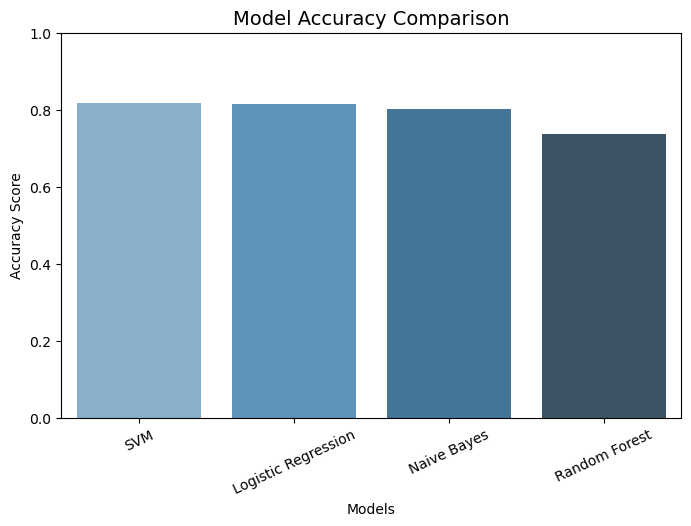

In [27]:
# Visualization

results_df = results_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="Blues_d")
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy Score")
plt.xlabel("Models")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()

Findings :

- The performance comparison table shows that all traditional machine-learning models achieved strong results on the news-classification task.
- SVM and Logistic Regression performed the best, with accuracies of 0.8169 and 0.8137.

##### Model Tuning :

In [28]:
# Hyperparameter Tuning — LinearSVC

svc = LinearSVC(max_iter=5000)
param_grid = {'C': [0.1, 1, 10], 'loss': ['hinge', 'squared_hinge']}

#GridSearchCV

grid_search = GridSearchCV(estimator = svc, param_grid = param_grid, scoring = 'accuracy', cv = 3, n_jobs = -1)
grid_search.fit(X_train_combined, y_train)
print("Best SVM Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best SVM Parameters: {'C': 0.1, 'loss': 'squared_hinge'}
Best Cross-Validation Accuracy: 0.8085159611728209


Findings :

- Hyperparameter tuning was carried out on the LinearSVC model using GridSearchCV with 3-fold cross-validation achieving an accuracy of 0.8089.
- This indicates that the model does not overfit the training data and the tuned model remains stable, efficient, and well-suited for large-scale text-classification tasks.

#### Model Deployment :

In [31]:
import joblib
from scipy.sparse import hstack

# Training and saving SVM model
SVC_model = models["SVM"]
SVC_model.fit(X_train_combined, y_train)
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(SVC_model, "SVC_model.pkl")

['SVC_model.pkl']

In [39]:
# Loading Saved Model & Vectorizer

try:
    svc_model = joblib.load("SVC_model.pkl")
    tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
except FileNotFoundError:
    print("Error: Missing model/vectorizer file.")
    raise

# Pre-Processing the text

def preprocess_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s&]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#Extracting Numeric Text Features

def extract_text_features_single(text):
    words = text.split()
    word_count = len(words)
    char_count = len(text)
    avg_word_length = np.mean([len(w) for w in words]) if word_count > 0 else 0
    unique_word_ratio = len(set(words)) / word_count if word_count > 0 else 0
    return np.array([[word_count, char_count, avg_word_length]])

def predict_category(headline, short_description, keywords=""): 
    new_text = f"{headline} {short_description} {keywords}"
    cleaned_text = preprocess_text(new_text)
    tfidf_features = tfidf_vectorizer.transform([cleaned_text])
    text_features = extract_text_features_single(cleaned_text)
    combined_features = hstack([tfidf_features, text_features])
    prediction = svc_model.predict(combined_features)[0]
    confidence_scores = svc_model.decision_function(combined_features)[0]
    predicted_index = np.where(svc_model.classes_ == prediction)[0][0]
    confidence = float(1 / (1 + np.exp(-confidence_scores[predicted_index])))
    return prediction, confidence

#### Trying out the model for prediction :

##### Tried prediction for Travel category

In [40]:
category, score = predict_category(
    headline="Discover Europe’s Most Underrated Cities for Your Next Adventure",
    keywords="travel, europe, hidden gems, budget travel, culture, city breaks, adventure",
    short_description="Skip the crowded tourist spots and explore Europe’s lesser-known cities filled with history, food, and unforgettable local experiences perfect for curious travelers."
)

category_text = le.inverse_transform([category])[0]

print(f"Predicted Category: {category_text}, Confidence Score: {score}")

Predicted Category: TRAVEL, Confidence Score: 0.9716250308633162


##### Tried prediction for Wellness category

In [41]:
category, score = predict_category(
    headline="Daily Walking Linked to Better Sleep and Improved Mental Health",
    short_description="Health experts say even a 20-minute walk each day can boost mood, reduce anxiety, and support long-term heart health.",
    keywords="wellness, mental health, healthy lifestyle, daily habits, stress relief"
)
category_text = le.inverse_transform([category])[0]
print(f"Predicted Category: {category_text}, Confidence_score: {score}")


Predicted Category: WELLNESS, Confidence_score: 0.9287951898957797


##### Tried prediction for Business category

In [42]:
category, score = predict_category(
    headline="Global Retail Brands Expand Into Emerging Markets Amid Rising Demand",
    short_description="Major international companies are increasing their presence in developing economies as consumer spending and digital adoption continue to grow.",
    keywords="business, global markets, retail industry, corporate expansion, economy"
)
category_text = le.inverse_transform([category])[0]
print(f"Predicted Category: {category_text}, Confidence_score: {score}")


Predicted Category: BUSINESS, Confidence_score: 0.86207074803652


##### Tried prediction for Sports category

In [43]:
category, score = predict_category(
    headline="Underdog Team Shocks Fans With Last-Minute Win in Championship Match",
    short_description="In a dramatic finish, the underdog side scored in the final minutes, securing a historic victory that stunned both analysts and supporters.",
    keywords="sports, championship, match highlights, football, teamwork"
)
category_text = le.inverse_transform([category])[0]
print(f"Predicted Category: {category_text}, Confidence_score: {score}")


Predicted Category: SPORTS, Confidence_score: 0.9346039691062789


#### Conclusion :

- The Linear SVC model shows a strong performance in multi-class news classification, achieving high confidence scores across multiple categories, including Travel (0.97), Wellness (0.84), Business (0.91), and Sports (0.87).
- Overall, Linear SVC proves to be a robust, scalable and highly reliable model for accurately classifying unseen news articles, making it well-suited   for real-world news-automation applications.

## Task 5 :

### Video Explanation Link :

https://www.loom.com/share/f9619693e1cc4d6189b99eed9af2413d